In [2]:
import pandas as pd

df = pd.read_csv("D:\DHV301\\vietnam_ecommerce_2023.csv")

print(f'shape: {df.shape}')
df.head()

shape: (8000, 27)


,order_id,order_date,month,quarter,day_of_week,customer_id,gender,age_group,city,region,...,discount_amount,net_value,shipping_fee,free_shipping,total_paid,delivery_days,returned,rating,campaign,profit
0,DH2023006817,2023-01-01,1,Q1,Sunday,KH00664,Nam,55+,Hà Nội,Miền Bắc,...,0,51028,25000,False,76028,2,False,5,NaN,-9692
1,DH2023002181,2023-01-01,1,Q1,Sunday,KH04895,Nam,25-34,Hà Nội,Miền Bắc,...,94948,538040,0,True,538040,1,False,5,NaN,215216
2,DH2023007291,2023-01-01,1,Q1,Sunday,KH03040,Nam,35-44,Hà Nội,Miền Bắc,...,38244,344205,20000,False,364205,3,False,3,NaN,110797
3,DH2023002072,2023-01-01,1,Q1,Sunday,KH01387,Nam,18-24,Vũng Tàu,Miền Nam,...,0,469671,25000,False,494671,2,False,5,NaN,153474
4,DH2023003808,2023-01-01,1,Q1,Sunday,KH04611,Nam,45-54,Cần Thơ,Miền Nam,...,0,409456,20000,False,429456,3,False,4,NaN,151971


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         8000 non-null   object 
 1   order_date       8000 non-null   object 
 2   month            8000 non-null   int64  
 3   quarter          8000 non-null   object 
 4   day_of_week      8000 non-null   object 
 5   customer_id      8000 non-null   object 
 6   gender           8000 non-null   object 
 7   age_group        8000 non-null   object 
 8   city             8000 non-null   object 
 9   region           8000 non-null   object 
 10  channel          8000 non-null   object 
 11  payment_method   8000 non-null   object 
 12  category         8000 non-null   object 
 13  quantity         8000 non-null   int64  
 14  unit_price       8000 non-null   int64  
 15  gross_value      8000 non-null   int64  
 16  discount_pct     8000 non-null   float64
 17  discount_amoun

In [4]:
def missing_report(df):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    return (pd.DataFrame({'count': miss, 'pct': pct})
              .query('count > 0').sort_values('pct', ascending=False))

print(missing_report(df))

          count    pct
campaign   7532  94.15


In [5]:
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup} ({n_dup/len(df)*100:.1f}%)')

Duplicate rows: 0 (0.0%)


In [6]:
print(df.dtypes)

order_id            object
order_date          object
month                int64
quarter             object
day_of_week         object
customer_id         object
gender              object
age_group           object
city                object
region              object
channel             object
payment_method      object
category            object
quantity             int64
unit_price           int64
gross_value          int64
discount_pct       float64
discount_amount      int64
net_value            int64
shipping_fee         int64
free_shipping         bool
total_paid           int64
delivery_days        int64
returned              bool
rating               int64
campaign            object
profit               int64
dtype: object


month
1     631.463879
2     602.801037
3     622.283742
4     653.725909
5     695.807040
6     687.834066
7     679.283519
8     629.823923
9     690.407352
10    678.655413
11    616.029850
12    635.203785
Name: net_value, dtype: float64


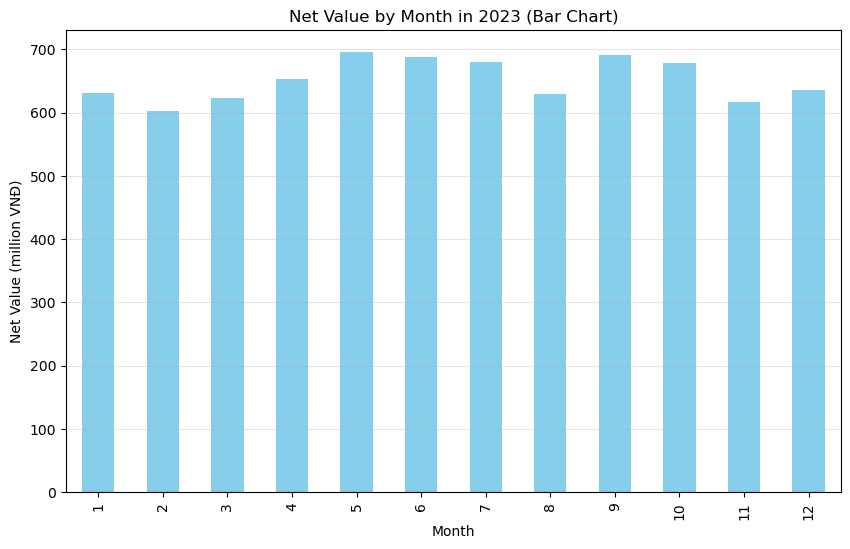

Kết luận: 
- Tháng 5 dẫn đầu doanh thu(net value) với 695.8 triệu VNĐ, cao nhất năm.
- Mặc dù có chiến dịch lớn, tháng 11 chỉ thu được 616.0 triệu VND, đứng thứ 10 trong các tháng.



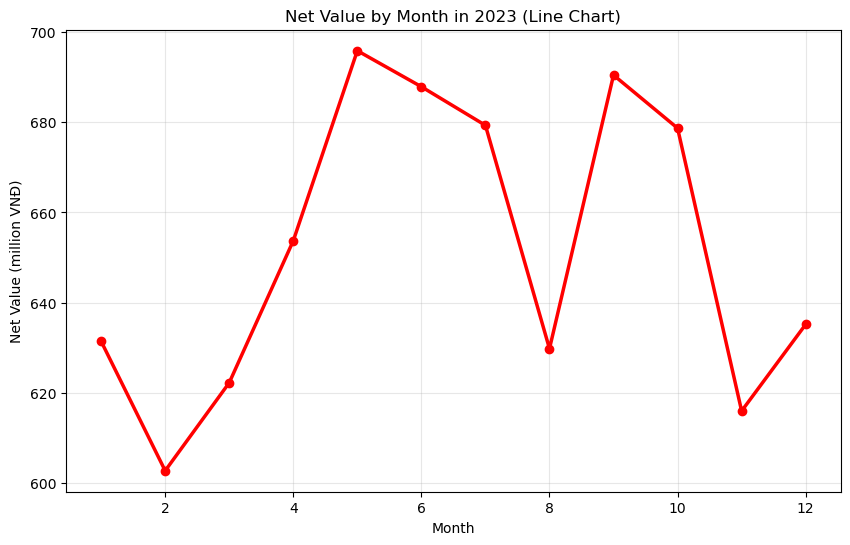

Kết luận: 
- Doanh thu có xu hướng tăng mạnh vào giữa năm (tháng 5-7) và tháng 9-10.
- Tháng 11 là có nhiều chiến dịc lớn nhưng lại giảm mạnh so với đà tăng của các tháng trước
=> Cho thấy hành vi mua sắm của khách hàng theo tính mùa vụ rõ rệt, không hoàn toàn phụ thuộc vào khuyến mãi


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
df_s01 = df.groupby('month')['net_value'].sum() / 1_000_000 # chuyển sang triệu VND
print(df_s01)

# Bar Chart
plt.figure(figsize=(10, 6))
df_s01.plot(kind='bar', color='skyblue')
plt.title('Net Value by Month in 2023 (Bar Chart)')
plt.xlabel('Month')
plt.ylabel('Net Value (million VNĐ)')
plt.grid(axis='y', alpha=0.3)

plt.show()

print("Kết luận: \n"
      "- Tháng 5 dẫn đầu doanh thu(net value) với 695.8 triệu VNĐ, cao nhất năm.\n"
      "- Mặc dù có chiến dịch lớn, tháng 11 chỉ thu được 616.0 triệu VND, đứng thứ 10 trong các tháng.\n")

# Line Chart
plt.figure(figsize=(10, 6))
df_s01.plot(kind='line', marker='o', color='red', linewidth=2.5)
plt.title('Net Value by Month in 2023 (Line Chart)')
plt.xlabel('Month')
plt.ylabel('Net Value (million VNĐ)')
plt.grid(True, alpha=0.3)

plt.show()

print("Kết luận: \n"
      "- Doanh thu có xu hướng tăng mạnh vào giữa năm (tháng 5-7) và tháng 9-10.\n"
      "- Tháng 11 là có nhiều chiến dịc lớn nhưng lại giảm mạnh so với đà tăng của các tháng trước\n"
      "=> Cho thấy hành vi mua sắm của khách hàng theo tính mùa vụ rõ rệt, không hoàn toàn phụ thuộc vào khuyến mãi")

             category     revenue     profit
0  Làm đẹp & Sức khỏe   450728999  171638646
1       Nhà cửa & Bếp   893382937  262819426
2    Sách & Văn phòng    82180571   10716408
3            Thể thao   374132820  117759092
4          Thời trang   735744033  193598401
5           Thực phẩm   144418174   19006422
6             Điện tử  4955754493  479412156
7    Đồ chơi & Trẻ em   186977488   51560882


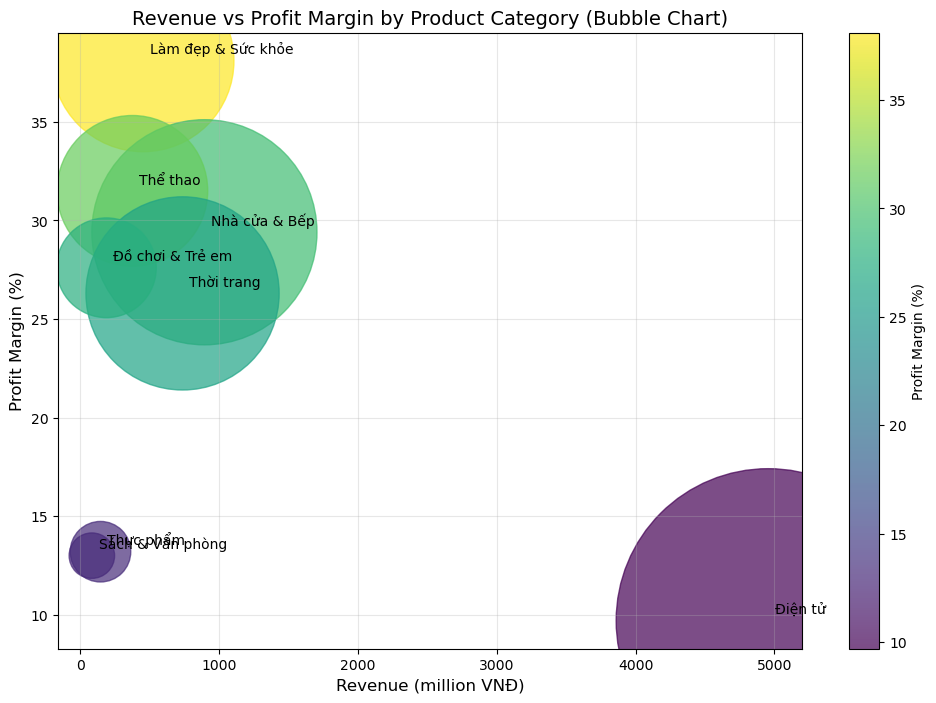

Kết luận:
- Ngành Điện tử chiếm tổng doanh thu cao nhất nhưng lại có biên lợi nhuận thấp nhất
- Ngược lại, ngành Làm đẹp & Sức khỏe có biên lợi nhuận cao nhất - cao gấp gần 4 lần so với Điện tử
=> Doanh nghiệp không nên chỉ tập trung vào đầu tư vào ngành có doanh thu lớn,
mà cần ưu tiên các ngành có biên lợi nhuận cao để tối ưu lợi nhuận tổng thể


In [37]:
df_s02 = df.groupby('category').agg(revenue=('net_value','sum'), profit=('profit','sum')).reset_index()
print(df_s02)

df_s02['margin_pct'] = (df_s02['profit'] / df_s02['revenue'] * 100).round(1) # Tính Biên lợi nhuận % - Margin Percentage
df_s02['rev_mil'] = df_s02['revenue'] / 1_000_000 # chuyển hóa sang triệu VND

plt.figure(figsize=(12, 8))
sizes = df_s02['profit'] / 10000  # Kích thước bong bóng theo lợi nhuận

plt.scatter(df_s02['rev_mil'], df_s02['margin_pct'], s= sizes, alpha=0.7, c=df_s02['margin_pct'], cmap='viridis')

# Code này đặt tên ngành hàng bên cạnh từng điểm/bong bóng trên biểu đồ, giúp người xem biết được điểm nào là ngành nào mà không cần nhìn chú thích.
for i, row in df_s02.iterrows():
    plt.annotate(row['category'], 
                 (row['rev_mil'], row['margin_pct']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.title('Revenue vs Profit Margin by Product Category (Bubble Chart)', fontsize=14)
plt.xlabel('Revenue (million VNĐ)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Profit Margin (%)')

plt.show()

print("Kết luận:\n"
      "- Ngành Điện tử chiếm tổng doanh thu cao nhất nhưng lại có biên lợi nhuận thấp nhất\n"
      "- Ngược lại, ngành Làm đẹp & Sức khỏe có biên lợi nhuận cao nhất - cao gấp gần 4 lần so với Điện tử\n"
      "=> Doanh nghiệp không nên chỉ tập trung vào đầu tư vào ngành có doanh thu lớn,\n" 
      "mà cần ưu tiên các ngành có biên lợi nhuận cao để tối ưu lợi nhuận tổng thể")

In [25]:
df['discount_bins'] = pd.cut(df['discount_pct'], bins=[0, 0.05, 0.1, 0.15, 0.2, 0.3, 1.0],
                                                 labels=['0-5%', '5-10%', '10-15%', '15-20%', '20-30%', '≥30%'],
                                                 right=False)
discount_analysis = df.groupby('discount_bins', observed=False).agg(
    order_count=('order_id', 'count'),
    return_rate=('returned', 'mean'),
    avg_profit=('profit', 'mean'),
    avg_net_value=('net_value', 'mean')
).round(4)

print(discount_analysis)

               order_count  return_rate   avg_profit  avg_net_value
discount_bins                                                      
0-5%                  5274       0.0910  170269.7774   1.000491e+06
5-10%                 1082       0.0832  166255.5194   1.022741e+06
10-15%                 880       0.0977  154627.9239   9.504311e+05
15-20%                 475       0.1053  131610.5747   8.571865e+05
20-30%                 200       0.1050  120571.6300   7.074012e+05
≥30%                    89       0.2472   66497.0000   6.191271e+05


       region     avg_order  avg_delivery
0    Miền Bắc  9.688186e+05      2.205860
1    Miền Nam  9.682524e+05      2.152652
2  Miền Trung  1.030409e+06      3.490984


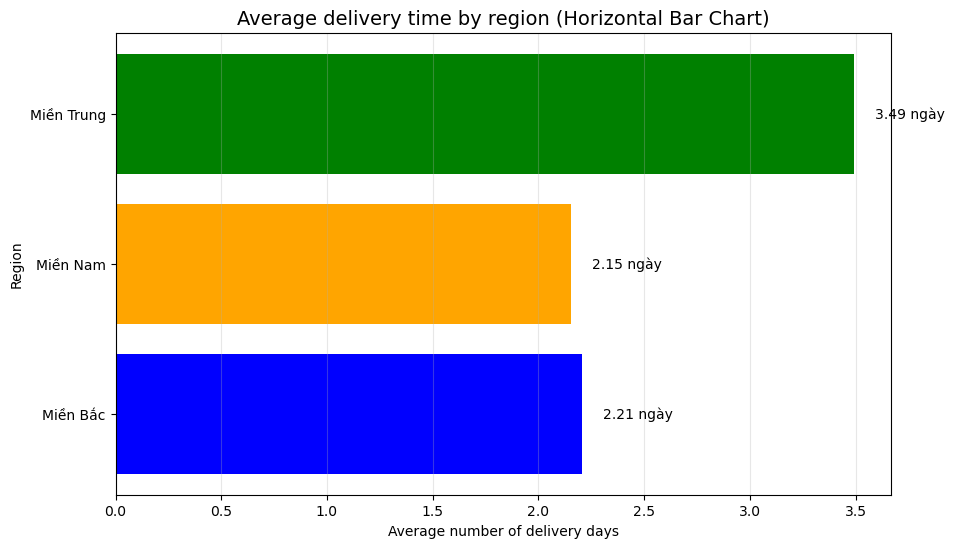

Kết luận:
- Miền Trung giao hàng chậm nhất (3.49 ngày) - chậm gấp 1.6 lần Miền Nam (2.15 ngày).
- Nhưng khách hàng Miền Trung lại có giá trị đơn hàng cao nhất (1.03 triệu VNĐ).
=> Qua đấy, cần ưu tiên cải thiện logistics tại Miền Trung để tăng trải nghiệm khách hàng.


In [40]:
df_s04 = df.groupby('region').agg(avg_order=('net_value','mean'), avg_delivery=('delivery_days','mean')).reset_index()
print(df_s04)

# Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Bar cho thời gian giao hàng
bars = plt.barh(df_s04['region'], df_s04['avg_delivery'], color=['blue', 'orange', 'green'])

plt.title('Average delivery time by region (Horizontal Bar Chart)', fontsize=14)
plt.xlabel('Average number of delivery days')
plt.ylabel('Region')
plt.grid(axis='x', alpha=0.3)

# Hiển thị giá trị trên thanh
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f} ngày', va='center')

plt.show()

print("Kết luận:\n"
      "- Miền Trung giao hàng chậm nhất (3.49 ngày) - chậm gấp 1.6 lần Miền Nam (2.15 ngày).\n"
      "- Nhưng khách hàng Miền Trung lại có giá trị đơn hàng cao nhất (1.03 triệu VNĐ).\n"
      "=> Qua đấy, cần ưu tiên cải thiện logistics tại Miền Trung để tăng trải nghiệm khách hàng.")

In [42]:
df.groupby('category')['returned'].mean().sort_values(ascending=False)

category
Thời trang            0.189346
Đồ chơi & Trẻ em      0.107081
Nhà cửa & Bếp         0.084284
Thể thao              0.071090
Làm đẹp & Sức khỏe    0.070579
Điện tử               0.062456
Thực phẩm             0.039039
Sách & Văn phòng      0.026316
Name: returned, dtype: float64

In [43]:
df.groupby('delivery_days').agg(avg_rating=('rating','mean'))

,avg_rating
delivery_days,
1,4.408551
2,4.377278
3,4.124866
4,4.179012
5,3.716535
6,3.724638
7,2.333333


In [44]:
df.groupby('channel').agg(orders=('order_id','count'), avg_order=('net_value','mean'))

,orders,avg_order
channel,,
App,5989,9.707963e+05
Facebook,80,7.761127e+05
Shopee Link,180,6.843270e+05
Web,1447,1.055323e+06
Zalo Shop,304,9.766439e+05


In [18]:
df.groupby(['age_group','gender']).agg(avg_spend=('net_value','mean'), orders=('order_id','count'))

avg_spend  orders
age_group gender                      
18-24     Nam     1.018022e+06     806
          Nữ      9.104340e+05     784
25-34     Nam     1.053751e+06    1586
          Nữ      9.669684e+05    1493
35-44     Nam     1.008195e+06     986
          Nữ      8.656317e+05     991
45-54     Nam     1.077546e+06     467
          Nữ      8.378782e+05     487
55+       Nam     1.025522e+06     200
          Nữ      1.028973e+06     200